# Assignment: Marketing Campaign Data Analysis

**Welcome, aspiring data analysts!** In this assignment, you will work with a real-world marketing campaign dataset. Your goal is to clean, transform, explore, and engineer new features to prepare the data for analysis and, eventually, for machine learning models.

Follow the steps in this guide to make the data ready for insightful analysis.

---

### Initial Setup
First, let's import the necessary libraries for our analysis.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style
sns.set(style='whitegrid')

---

## Part 1: Data Cleaning & Exploratory Data Analysis (EDA)

**Goal:** To understand the raw dataset, identify any initial problems, and perform basic cleaning.

### 1. Load and Explore the Data (First 5 mins(Days 😂) in Data)

**Task:** Load the `marketing_campaign.csv` file into a Pandas DataFrame. Remember that the separator in this file is a tab (`\t`).

In [3]:
# TASK: Load the dataset
df = pd.read_csv('marketing_campaign.csv', sep='\t')

**Task:** Use the `.head()`, `.info()`, `.describe()`, and `.shape` functions to get a first look at your data.

**Question:** Based on these initial outputs, what are your first observations about the data types, number of entries, and potential missing values?

In [4]:
df.shape

(2240, 29)

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Notes for cleaning Data

- Education , Marital_Status ,  --> (check values)
- Income (check if there are other columns) --> (Null values only)
- Dt_Customer (Check values and formate of data)
- Numerical columns (check if it unnecessary)

### 2. Data Cleansing

In [7]:
# Numerical columns (check if it unnecessary)
cols_to_drop = []

for col in df.select_dtypes(include=['number']).columns:
    if df[col].nunique() == 1:
        cols_to_drop.append(col)

print("Columns to drop:", cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)

Columns to drop: ['Z_CostContact', 'Z_Revenue']


In [8]:
# check the values of Education column
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

---

In [9]:
# check the values of Material_status column
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [10]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

print(df['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


In [11]:
# handle the values in DT_customer
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y', errors='coerce')
print("Number of NaT values:", df['Dt_Customer'].isna().sum())

Number of NaT values: 0


In [12]:
print(df['Dt_Customer'].head())

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]


In [13]:
# check if there are null values in other columns than Income
null_cols = df.columns[df.isnull().any()].tolist()
print("Columns with null values:", null_cols)

Columns with null values: ['Income']


# Handling Missing values

In [14]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

In [17]:
percentage_of_null = (df["Income"].isnull().sum() / df.shape[0]) * 100
percentage_of_null

1.0714285714285714

In [18]:
df.dropna(subset=["Income"], inplace=True)

In [19]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

# Dealing with outliers

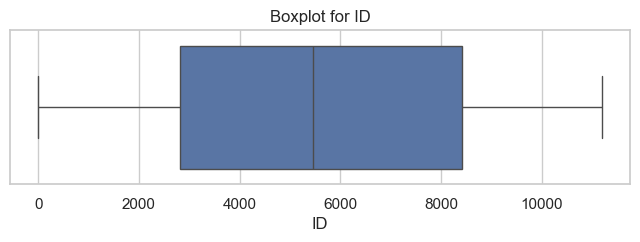

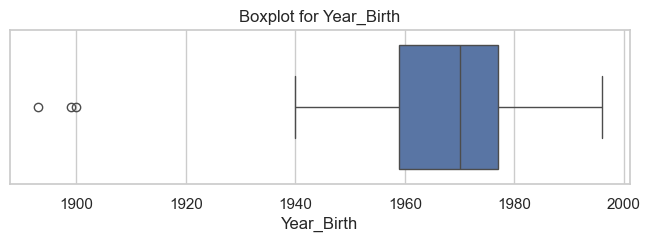

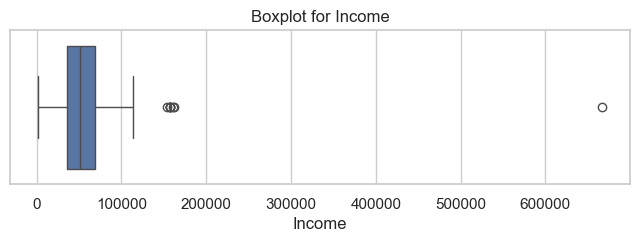

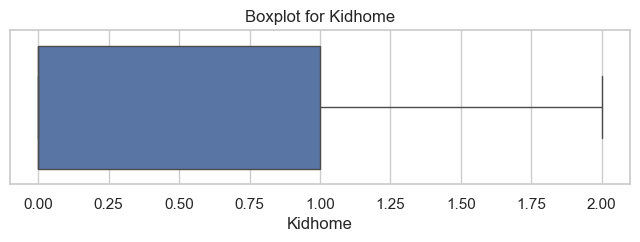

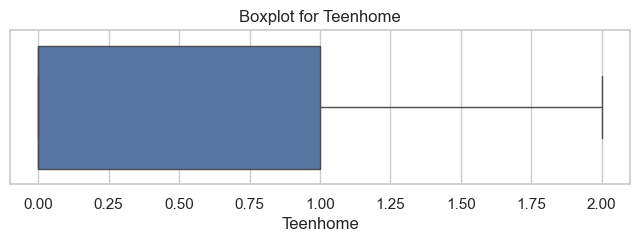

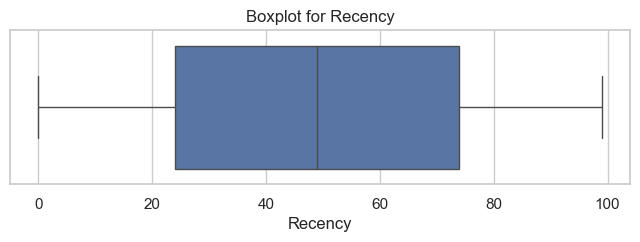

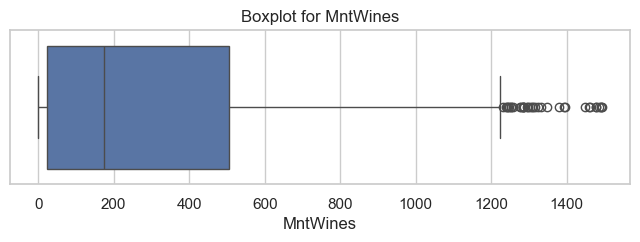

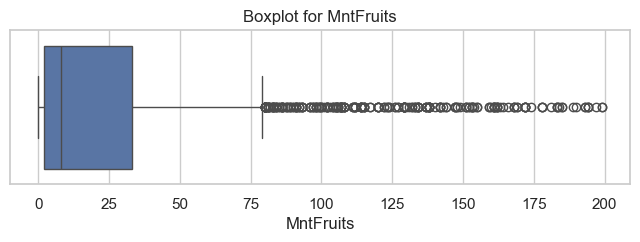

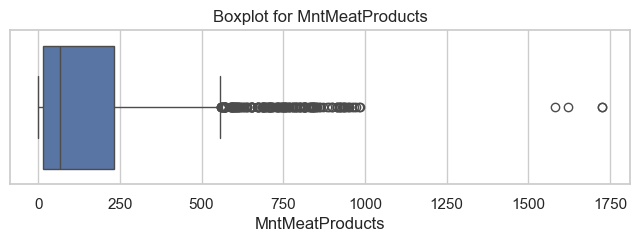

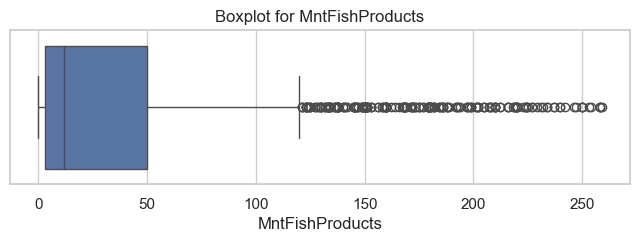

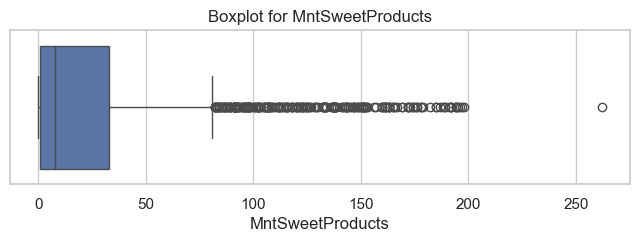

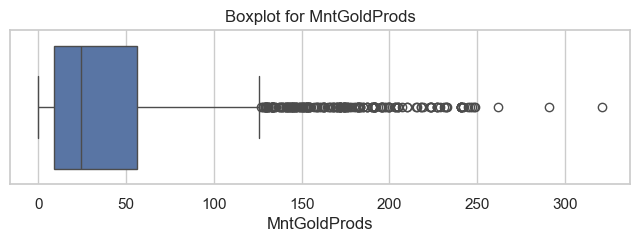

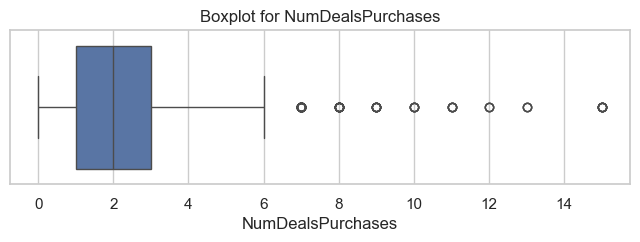

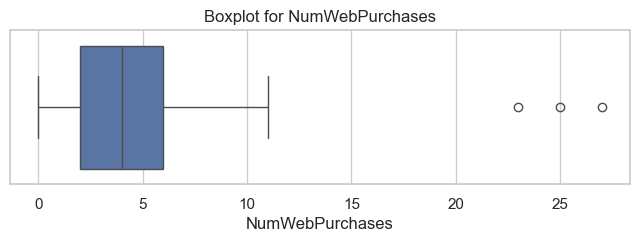

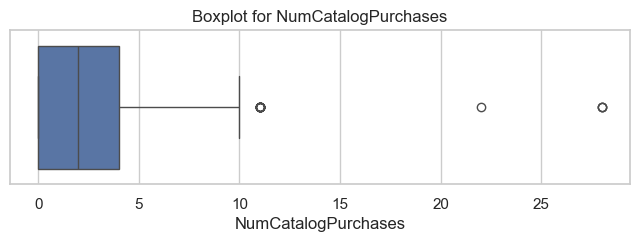

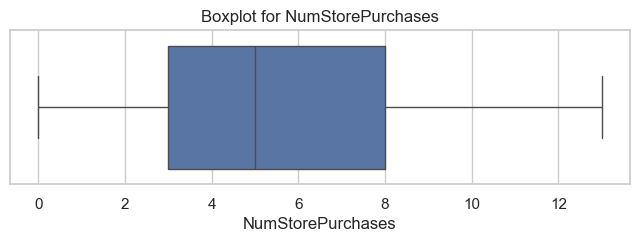

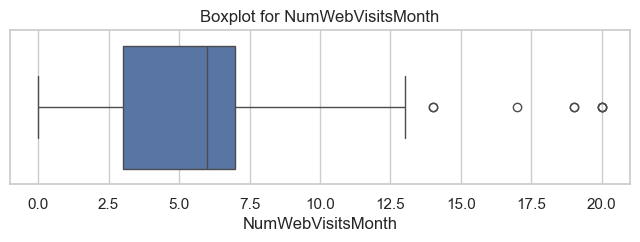

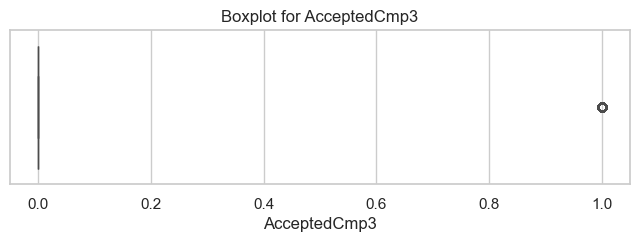

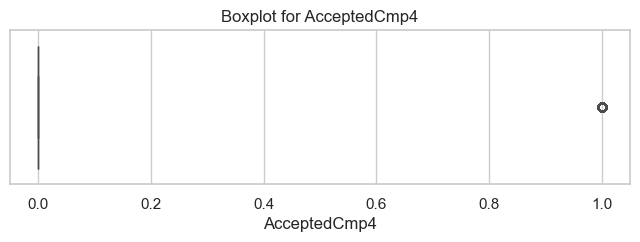

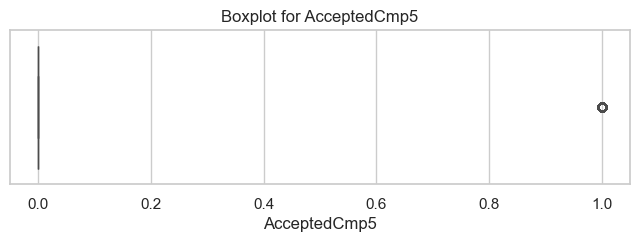

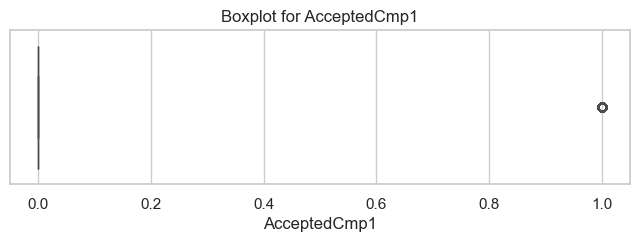

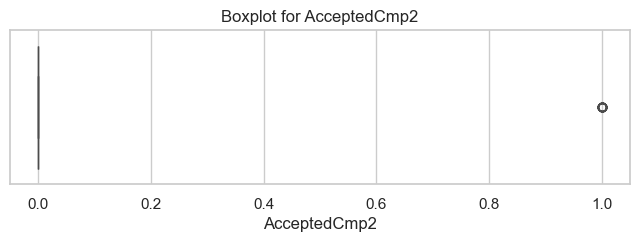

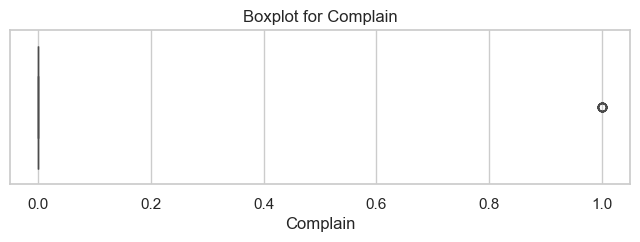

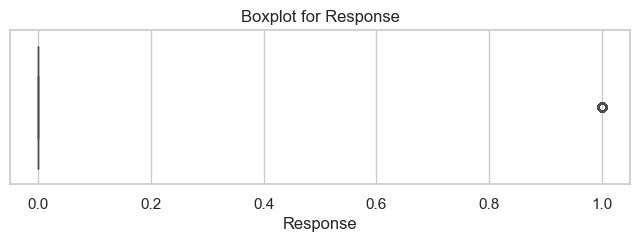

In [20]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
columns_with_outliers = []

for col in numerical_cols:
    col_data = df[col].dropna()
    
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    
    has_outliers = ((col_data < lower_bound) | (col_data > upper_bound)).any()
    
    if has_outliers:
        columns_with_outliers.append(col)
        
    plt.figure(figsize=(8, 2)) 
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()


In [21]:
print("Columns containing outliers:")
print(columns_with_outliers)

Columns containing outliers:
['Year_Birth', 'Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


## Notes
- AcceptedCmp1-5, Complain, Response -> Binary data (0/1) Natural outliers
- Drop the few rows from Income, Year_Birth 
- 'MntWines','MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds' -> Natural outliers representing VIP or    high-value customers (Use log transform -> compresse gape and preseve the data )
- 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumWebVisitsMonth' -> Natural outlier represent "Heavy Users"
(use Capping (99th Percentile) instead of dropping)


In [37]:
# Handling Year of birth -> 3 values (not logical value as age +100) 
df[df["Year_Birth"] <= 1920] 

# drop them
df = df[df["Year_Birth"] >= 1920]


In [38]:
# Handling Incom 
df['Income'].describe()

count      2212.000000
mean      51958.810579
std       21527.278844
min        1730.000000
25%       35233.500000
50%       51371.000000
75%       68487.000000
max      162397.000000
Name: Income, dtype: float64

In [ ]:
# remove the the max value only as it is not logical value the other (rich people)
df[df['Income'] > 200000] 
df = df[df['Income'] < 200000]

In [48]:
mnt_cols = [
    'MntWines', 
    'MntFruits', 
    'MntMeatProducts', 
    'MntFishProducts', 
    'MntSweetProducts', 
    'MntGoldProds'
]

for col in mnt_cols:
    df[col] = np.log1p(df[col])

display(df[mnt_cols].head())

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,6.455199,4.488636,6.304449,5.153292,4.488636,4.488636
1,2.484907,0.693147,1.945910,1.098612,0.693147,1.945910
2,6.056784,3.912023,4.852030,4.718499,3.091042,3.761200
3,2.484907,1.609438,3.044522,2.397895,1.386294,1.791759
4,5.159055,3.784190,4.779123,3.850148,3.332205,2.772589


In [49]:
num_cols = [
    'NumDealsPurchases', 
    'NumWebPurchases', 
    'NumCatalogPurchases', 
    'NumWebVisitsMonth'
]

for col in num_cols:
    cap_value = df[col].quantile(0.99)
    df[col] = np.where(df[col] > cap_value, cap_value, df[col])

display(df[num_cols].head())

,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumWebVisitsMonth
0,3.0,8.0,10.0,7.0
1,2.0,1.0,1.0,5.0
2,1.0,8.0,2.0,4.0
3,2.0,2.0,0.0,6.0
4,5.0,5.0,3.0,5.0


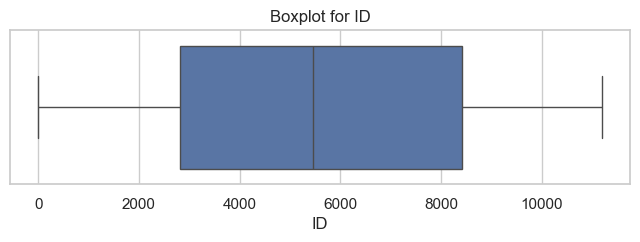

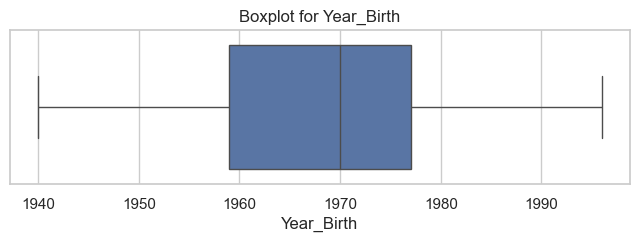

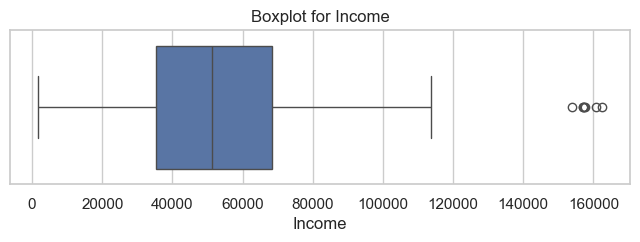

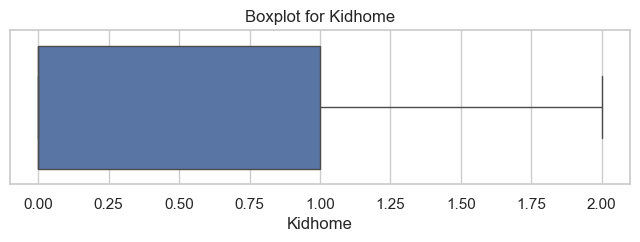

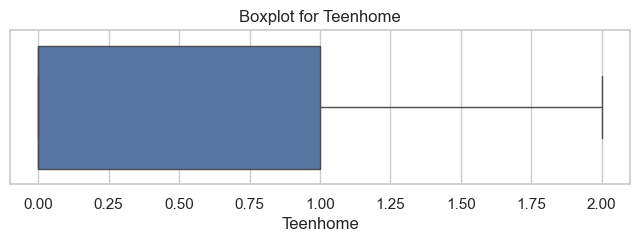

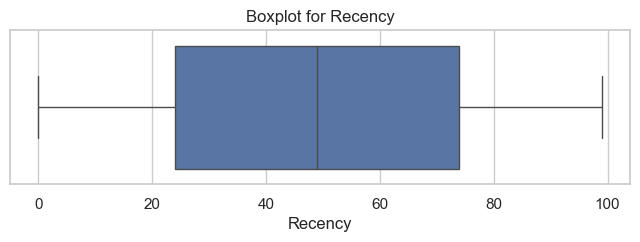

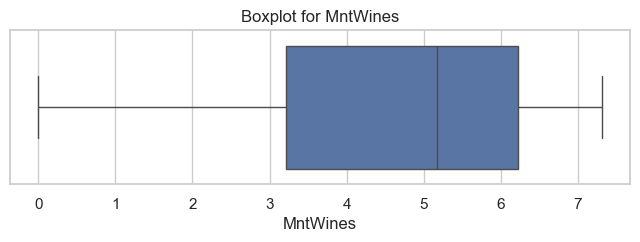

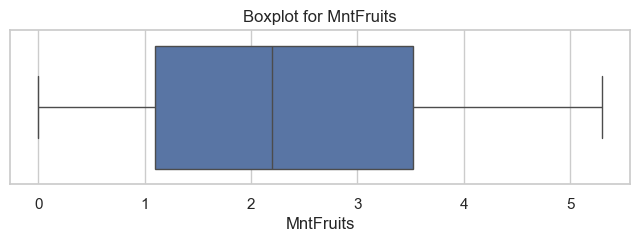

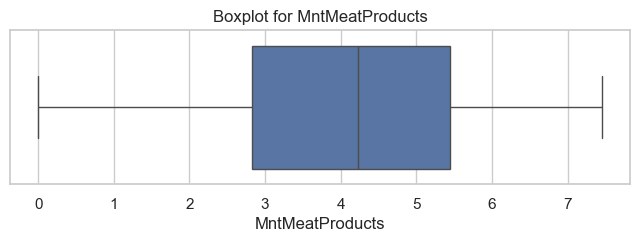

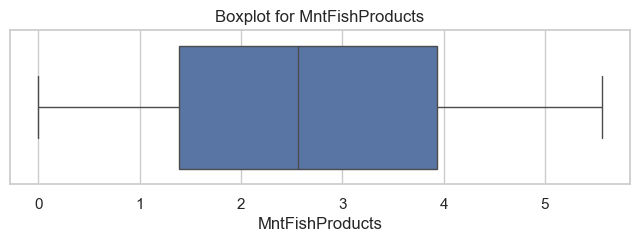

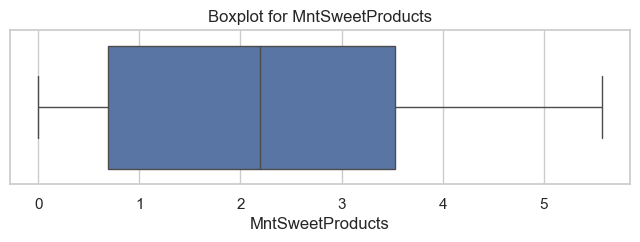

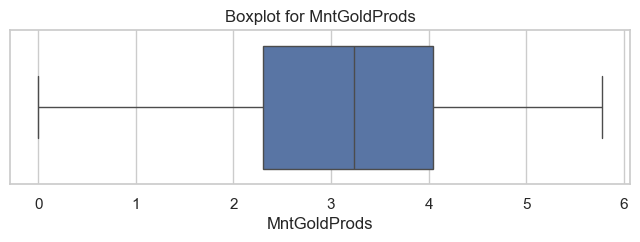

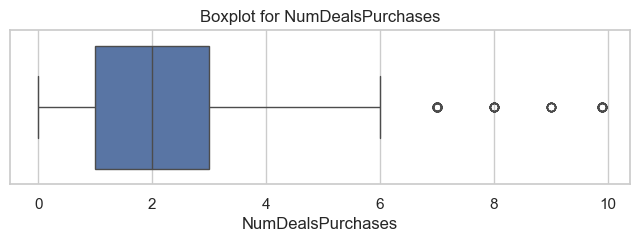

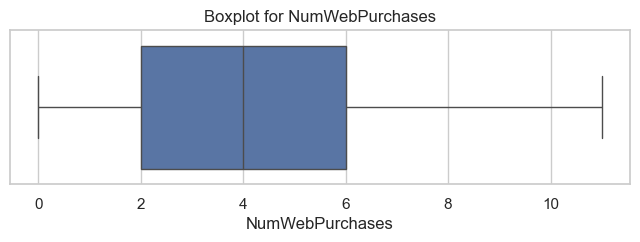

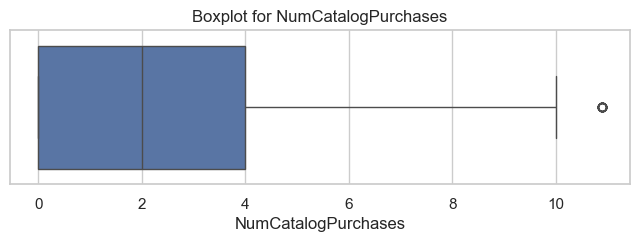

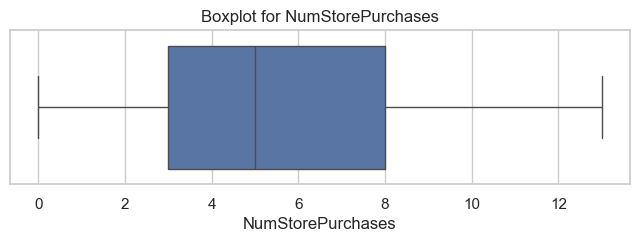

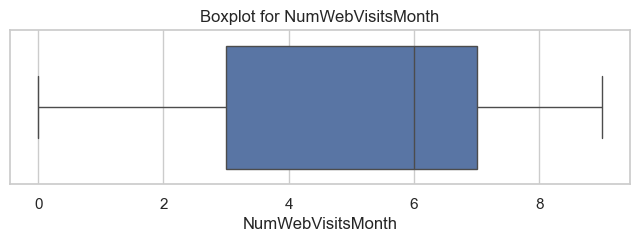

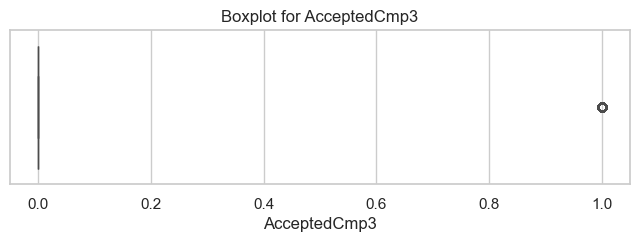

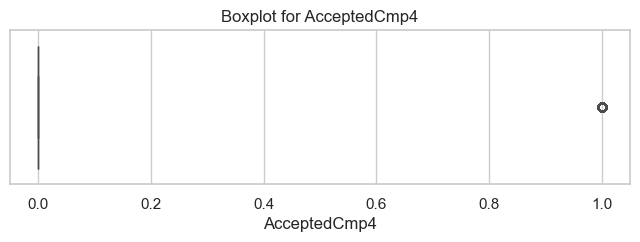

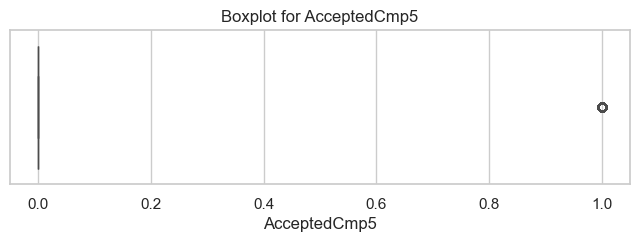

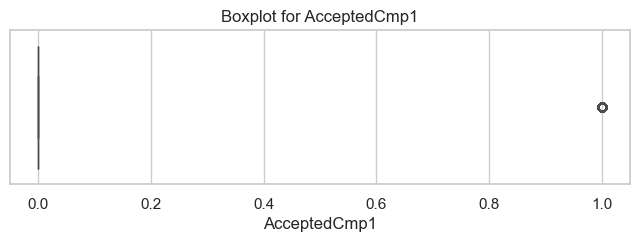

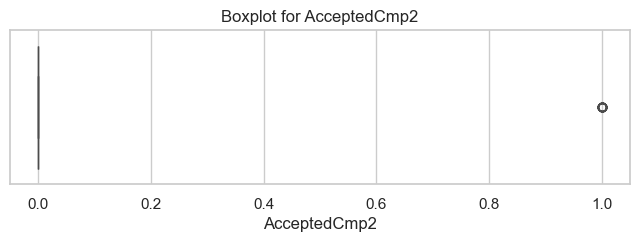

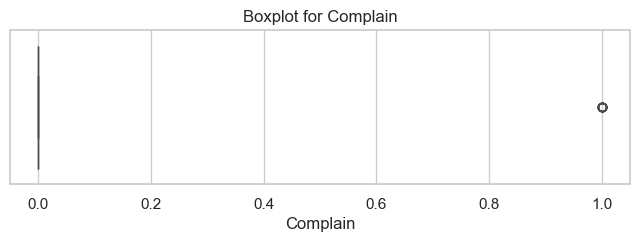

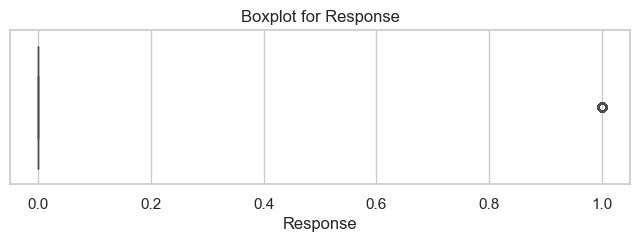

In [50]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
columns_with_outliers = []

for col in numerical_cols:
    col_data = df[col].dropna()
    
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    
    has_outliers = ((col_data < lower_bound) | (col_data > upper_bound)).any()
    
    if has_outliers:
        columns_with_outliers.append(col)
        
    plt.figure(figsize=(8, 2)) 
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()
